In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
import random

import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

SEED_VALUE=123
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.keras.utils.set_random_seed(SEED_VALUE)

2026-04-23 22:17:07.209251: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776982627.456349      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776982627.526670      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776982628.106162      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776982628.106266      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776982628.106270      55 computation_placer.cc:177] computation placer alr

In [2]:
df = pd.read_parquet('/kaggle/input/datasets/aullyanadinek/1a-dataset/1A.parquet')
df

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,sowing_date,harvest_date,total_days,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status,yield
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,None,...,2024-01-08,2024-05-09,122,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild,44080.7
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,...,2024-02-04,2024-05-26,112,SENS0002,2024-04-21,16.613022,70.869009,0.58,None,53899.8
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,...,2024-02-03,2024-06-26,144,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild,29311.6
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,...,2024-02-21,2024-07-04,134,SENS0004,2024-05-14,31.071298,85.519998,0.44,None,42278.0
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,None,...,2024-02-05,2024-05-20,105,SENS0005,2024-04-13,16.56854,81.691720,0.84,Severe,49799.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,FARM0496,Central USA,Rice,42.85,6.7,30.85,52.35,79.58,7.25,Manual,...,2024-01-16,2024-06-02,138,SENS0496,2024-05-08,30.386623,76.147700,0.59,Mild,42514.0
496,FARM0497,North India,Soybean,34.22,6.75,17.46,256.23,45.14,5.78,None,...,2024-01-01,2024-04-14,104,SENS0497,2024-01-19,18.832748,75.736924,0.85,Severe,37085.4
497,FARM0498,North India,Cotton,15.93,5.72,17.03,288.96,57.87,7.69,Drip,...,2024-01-02,2024-05-09,128,SENS0498,2024-04-20,23.262016,81.992230,0.71,Mild,26044.1
498,FARM0499,Central USA,Soybean,38.61,6.2,17.08,279.06,73.09,9.60,Drip,...,2024-01-25,2024-06-04,131,SENS0499,2024-03-02,19.764989,84.426869,0.77,Severe,25863.6


# a) EDA & Data Preprocessing

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   farm_id              500 non-null    object 
 1   region               500 non-null    object 
 2   crop_type            500 non-null    object 
 3   soil_moisture_%      500 non-null    float64
 4   soil_pH              500 non-null    object 
 5   temperature_C        500 non-null    float64
 6   rainfall_mm          500 non-null    float64
 7   humidity_%           500 non-null    float64
 8   sunlight_hours       499 non-null    float64
 9   irrigation_type      350 non-null    object 
 10  fertilizer_type      500 non-null    object 
 11  pesticide_usage_ml   500 non-null    float64
 12  sowing_date          500 non-null    object 
 13  harvest_date         500 non-null    object 
 14  total_days           500 non-null    int64  
 15  sensor_id            500 non-null    obj

Dataset ini terdiri dari 500 baris dan 22 columns.

Terdapat missing values pada sunlight_hours, irrigation_type, dan crop_disease_status. Selain itu, soil_pH dan latitude harusnya memiliki tipe data numerik, namun pada dataset ini, tipe datanya object. Hal ini menunjukkan ada kemungkinan anomali dalam data.

Variable unique identifier seperti farm_id, sensor_id, dan timestamp tidak memberikan meaningful information untuk memprediksi target sehingga akan didrop.

In [4]:
df = df.drop(columns=['farm_id', 'sensor_id', 'timestamp'])

# Check Duplicate

In [5]:
sum(df.duplicated())

0

## Check Inconsistent Value

In [6]:
cat_col = [c for c in df.columns if df[c].dtype == 'object']
for c in cat_col:
    print(f"Total unique values in {c}: {df[c].nunique()}")
    print(df[c].value_counts(), "\n")

Total unique values in region: 5
region
Central USA    109
East Africa    107
North India     99
South USA       94
South India     91
Name: count, dtype: int64 

Total unique values in crop_type: 5
crop_type
Maize      111
Soybean    108
Cotton     107
Wheat       92
Rice        82
Name: count, dtype: int64 

Total unique values in soil_pH: 186
soil_pH
5.97    7
6.33    7
7.3     6
6.78    6
6.3     6
       ..
6.47    1
6,42    1
7.08    1
5.82    1
6.71    1
Name: count, Length: 186, dtype: int64 

Total unique values in irrigation_type: 3
irrigation_type
Sprinkler    121
Manual       118
Drip         111
Name: count, dtype: int64 

Total unique values in fertilizer_type: 3
fertilizer_type
Inorganic    167
Mixed        167
Organic      166
Name: count, dtype: int64 

Total unique values in sowing_date: 84
sowing_date
2024-03-05    15
2024-03-07    11
2024-02-02     9
2024-03-04     9
2024-01-27     9
              ..
2024-01-21     3
2024-02-08     3
2024-01-15     2
2024-01-12     

Ternyata terdapat inkonsistensi pada soil_pH, yaitu penggunaan tanda "," untuk decimal yang seharusnya menggunakan "."
Akibatnya tipe datanya menjadi object, bukan numerik. Oleh karena itu, harus ditangani dengan mengubah tanda koma menjadi titik, lalu mengubah tipe datanya menjadi numeric

In [7]:
df['soil_pH'] = df['soil_pH'].astype(str).str.replace(',', '.', regex=False)
df['soil_pH'] = pd.to_numeric(df['soil_pH'], errors='raise')

In [8]:
# mengecek kembali
df['soil_pH'].dtype

dtype('float64')

Selain soil_pH, variable latitude juga seharusnya bertipe numeric, namun didataset ini bertipe object sehingga harus dicek lebih lanjut

In [9]:
mask_lat = pd.to_numeric(df['latitude'], errors='coerce').isna()
df[mask_lat]

,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,fertilizer_type,pesticide_usage_ml,sowing_date,harvest_date,total_days,latitude,longitude,NDVI_index,crop_disease_status,yield
128,North India,Maize,18.81,5.99,27.50,198.45,49.78,4.64,Manual,Organic,47.70,2024-02-27,2024-07-05,129,,78.612324,0.79,Mild,35195.6
380,South India,Cotton,26.11,6.31,28.15,236.06,76.30,5.82,Manual,Mixed,35.32,2024-03-22,2024-07-15,115,,70.277518,0.37,None,52185.6


Ternyata terdapat 2 row yang berisi string kosong pada variable latitude. Oleh karena itu, perlu diubah menjadi missing value untuk selanjutnya ditangani.

In [10]:
df['latitude'] = df['latitude'].replace('', np.nan)
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')

# Check Numerical Variable

In [11]:
df.describe()

,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,pesticide_usage_ml,total_days,latitude,longitude,NDVI_index,yield
count,500.000000,500.000000,500.000000,500.000000,500.000000,499.000000,500.000000,500.000000,498.000000,500.000000,500.000000,500.000000
mean,26.750140,6.523980,24.675740,181.685740,65.194460,7.031904,26.586980,119.114000,22.464064,80.392248,0.602060,40329.269400
std,10.150053,0.585558,5.348899,72.293091,14.642849,1.692908,13.202429,18.403107,7.285843,5.910664,0.175402,11744.330399
min,10.160000,5.510000,15.000000,50.170000,40.230000,4.010000,5.050000,-50.000000,10.004243,70.020021,0.300000,20235.600000
25%,17.890000,6.030000,20.295000,119.217500,51.865000,5.665000,14.945000,105.000000,16.274905,75.374713,0.447500,29948.200000
50%,25.855000,6.530000,24.655000,191.545000,65.685000,7.000000,25.980000,118.500000,22.032474,80.650284,0.610000,40716.900000
75%,36.022500,7.040000,29.090000,239.035000,77.995000,8.470000,38.005000,134.000000,28.557783,85.654629,0.750000,50621.100000
max,44.980000,7.500000,34.840000,298.960000,90.000000,10.000000,49.940000,150.000000,34.981531,89.991901,0.900000,59982.900000


Dengan menggunakan .describe() ini kita bisa mengecek apakah ada anomali di numerical data. Di sini kita bisa lihat dari nilai max dan min untuk mengetahui apakah range data masih masuk akal.

Jika dilihat, terdapat anomali pada total_days, yaitu terdapat nilai negatif, padahal total_days tidak mungkin negatif, sehingga harus ditangani.

In [12]:
df[df['total_days']<0]

,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,fertilizer_type,pesticide_usage_ml,sowing_date,harvest_date,total_days,latitude,longitude,NDVI_index,crop_disease_status,yield
390,North India,Maize,21.02,7.46,18.29,65.37,77.96,7.96,Sprinkler,Mixed,7.6,2024-03-23,2024-08-11,-50,34.316529,78.386106,0.83,Moderate,46414.5


In [13]:
df.loc[df['total_days'] < 0, 'total_days'] = np.nan

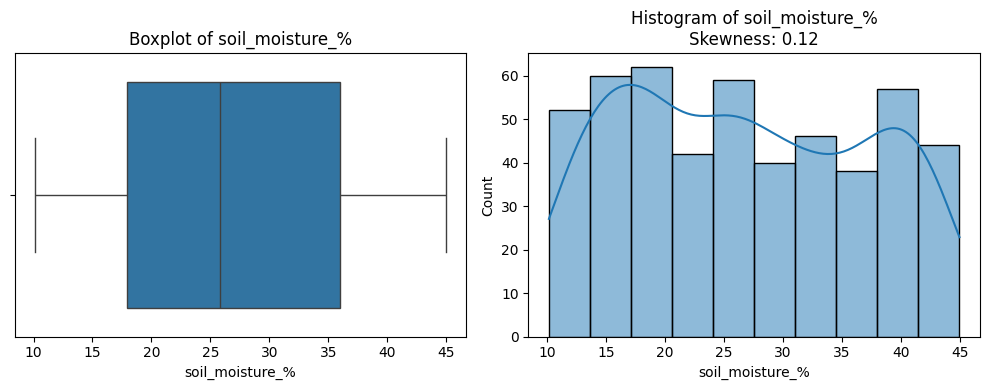

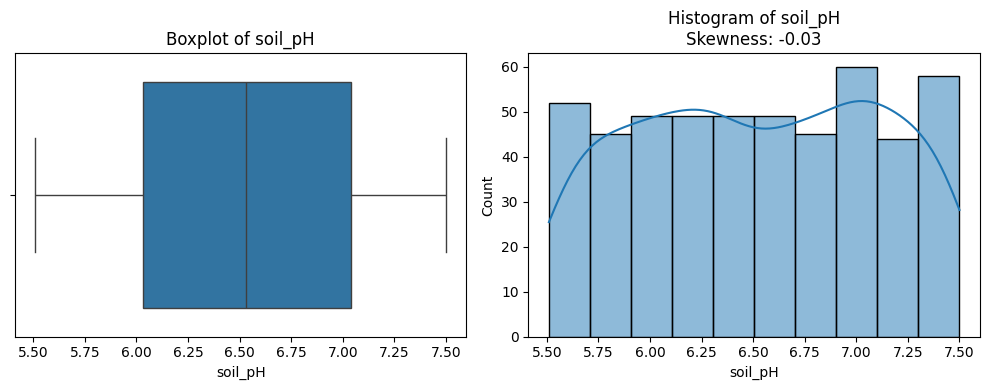

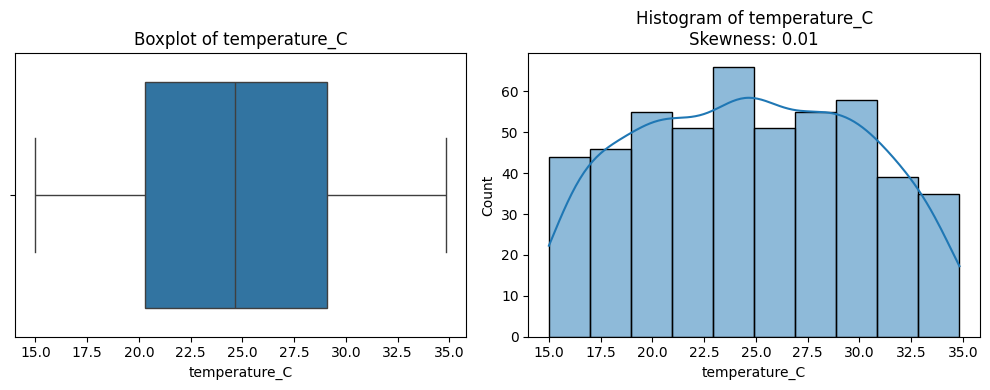

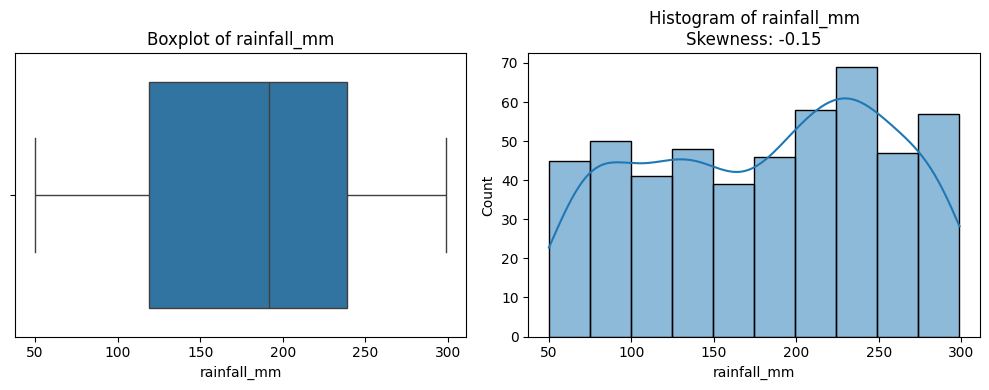

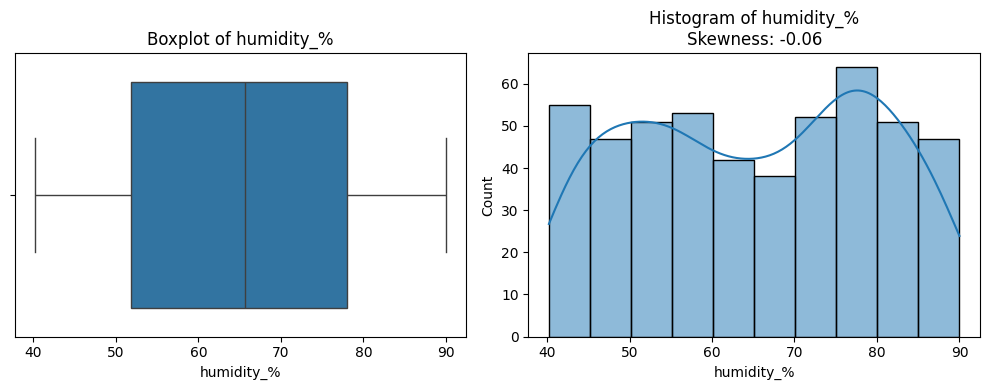

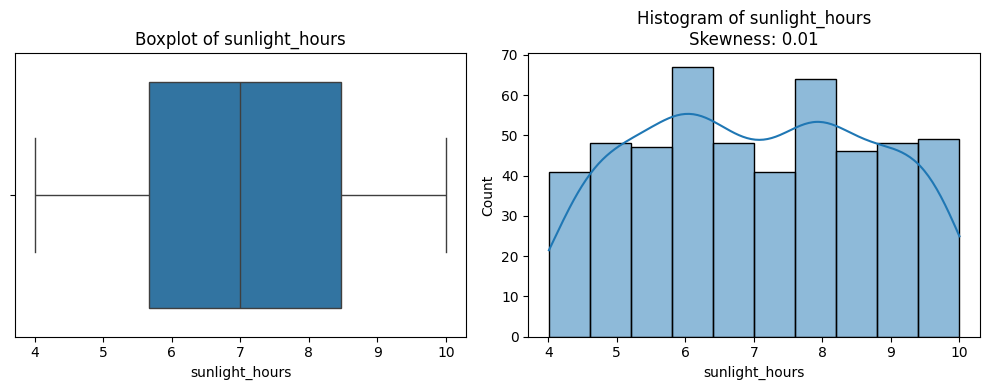

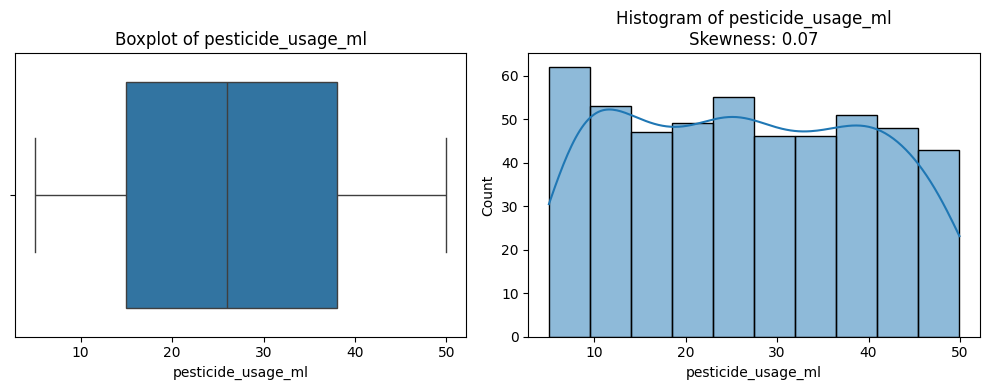

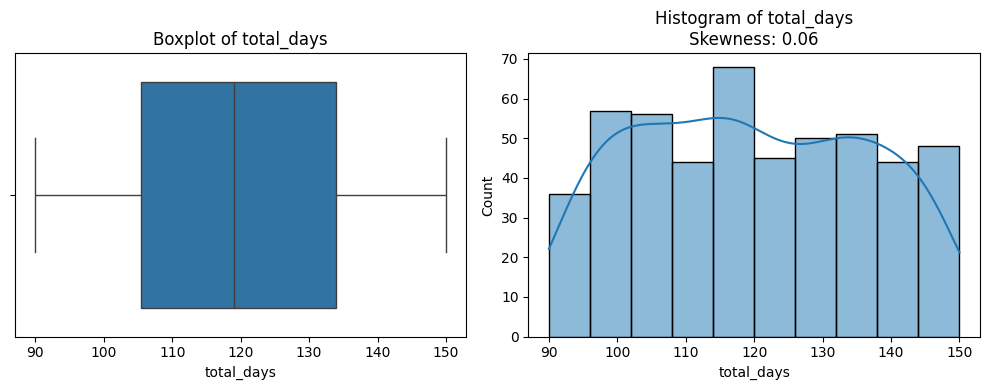

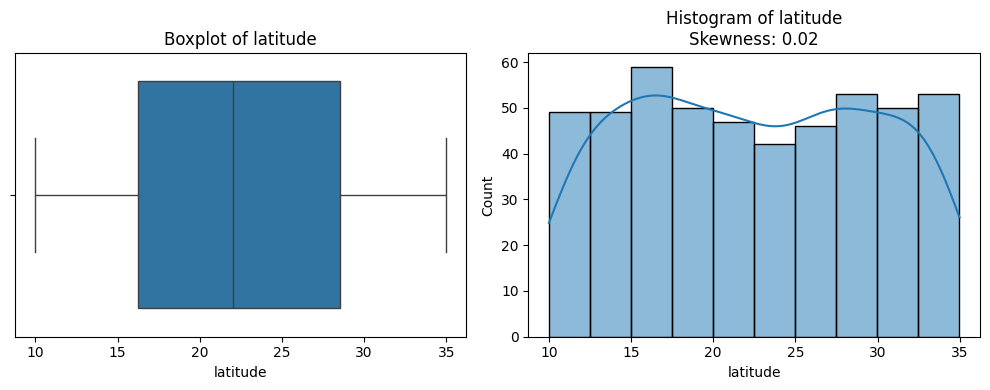

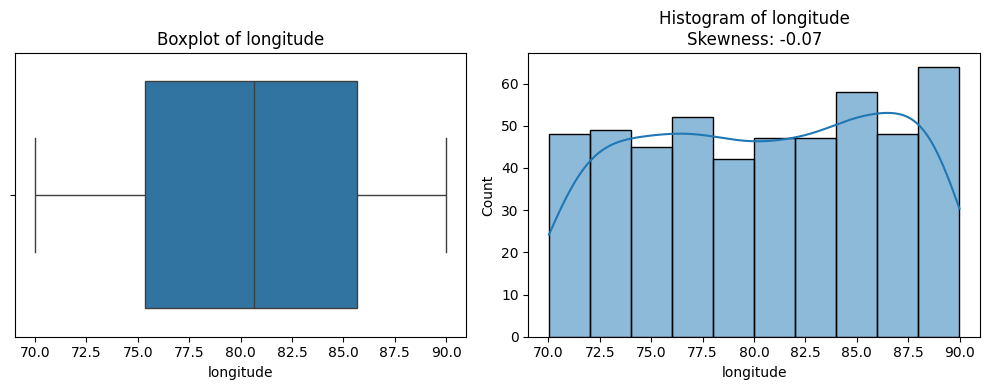

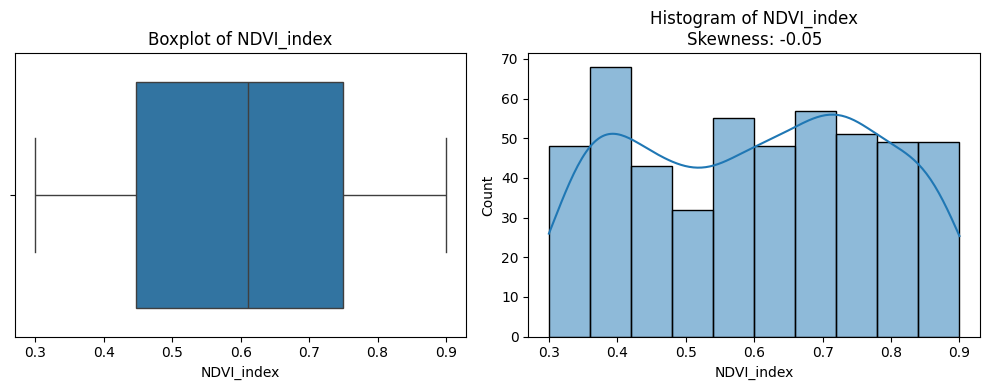

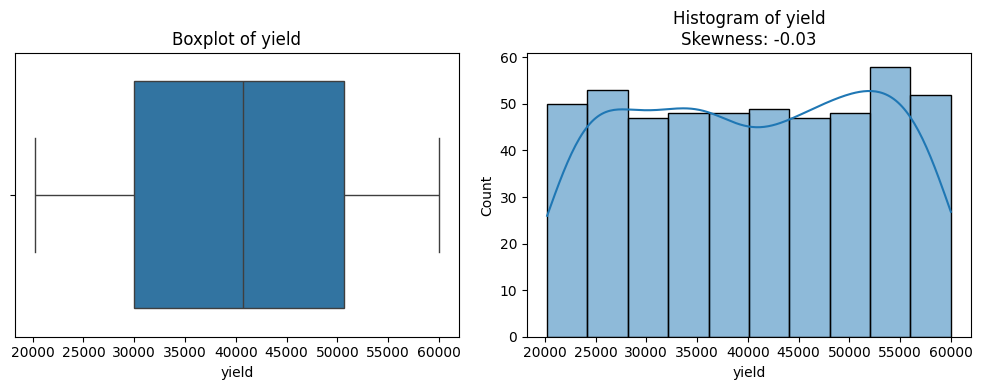

In [14]:
num_col = [c for c in df.columns if df[c].dtype != 'object']

for col in num_col:
    skew_val = df[col].skew()
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    sns.boxplot(x=df[col], ax=axes[0])
    axes[0].set_title(f'Boxplot of {col}')
    
    sns.histplot(df[col].dropna(), kde=True, ax=axes[1])
    axes[1].set_title(f'Histogram of {col}\nSkewness: {skew_val:.2f}')
    
    plt.tight_layout()
    plt.show()

## Handling Missing Value in total_days
Variable total_days didapat dengan mengurangkan harvest_date dengan sowing_date. Proses ini dilakukan sebelum splitting karena hanya berupa transformasi langsung dari data, bukan imputasi berbasis statistik seperti mean/median, sehingga aman dan tidak menyebabkan data leakage.

In [15]:
df['sowing_date'] = pd.to_datetime(df['sowing_date'])
df['harvest_date'] = pd.to_datetime(df['harvest_date'])

In [16]:
df.loc[df['total_days'].isna(), 'total_days'] = (df['harvest_date'] - df['sowing_date']).dt.days

harvest_date dan sowing_date akan saya drop karena sudah ada variable turunannya, yaitu total_days dimana lebih informatif dibandingkan hanya data tanggal

In [17]:
df = df.drop(columns=['sowing_date', 'harvest_date'])

## Correlation

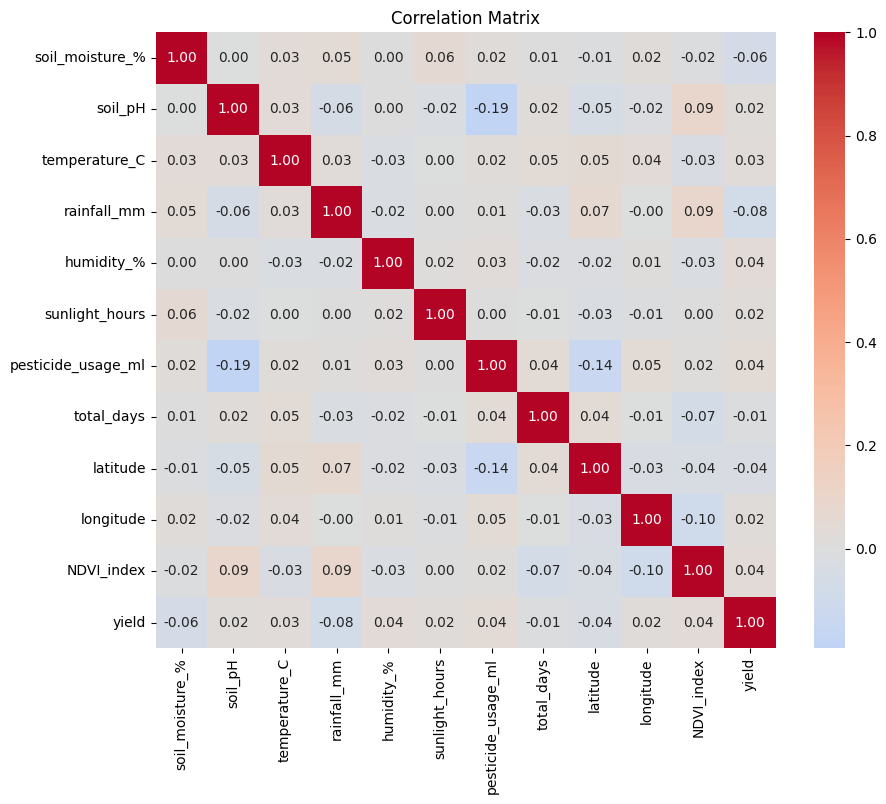

In [18]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

Semua variable numerik memiliki korelasi <0.1 dengan variable target (yield)

## Splitting Dataset
Split dataset menjadi train:val:test dengan proporsi 70:10:20

In [19]:
x = df.drop(columns='yield')
y = df['yield']

In [20]:
X_train, x_test, Y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(X_train, Y_train, test_size=0.125, random_state=42)
print(x_train.shape,y_train.shape)
print(x_val.shape,y_val.shape)
print(x_test.shape,y_test.shape)

(350, 16) (350,)
(50, 16) (50,)
(100, 16) (100,)


## Handling Rest of Missing Value
Untuk sunlight_hours akan diimpute menggunakan median, latitude juga akan menggunakan median, namun berdasarkan regionnya

Untuk categorical variable seperti irrigation_type dan crop_disease_status, akan diimpute menggunakan modus

In [21]:
cols = ['irrigation_type', 'crop_disease_status']

for col in cols:
    mode_train = x_train[col].mode()[0]
    x_train[col] = x_train[col].fillna(mode_train)
    x_val[col] = x_val[col].fillna(mode_train)
    x_test[col] = x_test[col].fillna(mode_train)

In [22]:
sun_med = x_train['sunlight_hours'].median()

x_train['sunlight_hours'] = x_train['sunlight_hours'].fillna(sun_med)
x_val['sunlight_hours']   = x_val['sunlight_hours'].fillna(sun_med)
x_test['sunlight_hours']  = x_test['sunlight_hours'].fillna(sun_med)

In [23]:
map_med = x_train.groupby('region')['latitude'].median()
global_med = x_train['latitude'].median()

def impute_latitude(df, med_reg, med_global):
    df['latitude'] = df['latitude'].fillna(df['region'].map(med_reg))
    df['latitude'] = df['latitude'].fillna(med_global) 
    return df

x_train = impute_latitude(x_train, map_med, global_med)
x_val   = impute_latitude(x_val, map_med, global_med)
x_test  = impute_latitude(x_test, map_med, global_med)

## Feature Engineering
Untuk categorical column, yaitu region, crop_type, fertilizer_type, dan irrigation_type tidak memiliki urutan pasti (nominal variable) sehingga akan diencode menggunakan OneHot Encoder. Sedangkan crop_disease_status memiliki hierarki dari None, Mild, Moderate, Severe sehingga akan diencode menggunakan OrdinalEncoder. Untuk numerical akan discaling menggunakan Standard Scaler

In [ ]:
ordinal_col = ['crop_disease_status']
nom_cols = ['region', 'crop_type', 'fertilizer_type', 'irrigation_type']
num_cols = [c for c in x_train.columns if c not in nom_cols + ordinal_col and c != 'yield']

ordinal_encoder = OrdinalEncoder(
    categories=[['None', 'Mild', 'Moderate', 'Severe']]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), nom_cols),
        ('ord', ordinal_encoder, ordinal_col)
    ],
    remainder='drop'
)

x_train = preprocessor.fit_transform(x_train)
x_val   = preprocessor.transform(x_val)
x_test  = preprocessor.transform(x_test)

# b) Baseline Model

In [25]:
input_dim = x_train.shape[1]
print(input_dim)

28


In [26]:
tf.keras.utils.set_random_seed(123)

baseline_model = Sequential([
    Dense(84, activation='relu', input_shape=(input_dim,)),
    Dense(56, activation='relu'),
    Dense(1, activation='linear')
])

baseline_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

baseline_model.summary()

base_run = baseline_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=90,
    batch_size = 32,
    verbose=1
)

2026-04-23 22:17:39.162806: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 84)             │         2,436 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 56)             │         4,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            57 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,253 (28.33 KB)

 Trainable params: 7,253 (28.33 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1790145536.0000 - mae: 40515.4766 - rmse: 42308.8672 - val_loss: 1555405312.0000 - val_mae: 37794.8516 - val_rmse: 39438.6289
Epoch 2/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1790028288.0000 - mae: 40514.0156 - rmse: 42307.4805 - val_loss: 1555277696.0000 - val_mae: 37793.1641 - val_rmse: 39437.0078
Epoch 3/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1789875968.0000 - mae: 40512.1211 - rmse: 42305.6797 - val_loss: 1555090944.0000 - val_mae: 37790.6914 - val_rmse: 39434.6406
Epoch 4/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1789650048.0000 - mae: 40509.3164 - rmse: 42303.0117 - val_loss: 1554806656.0000 - val_mae: 37786.9219 - val_rmse: 39431.0352
Epoch 5/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1789304960.0000 - mae: 40505.0273 - rmse: 42298.9336 - val_loss: 1554375936.0000 - val_mae: 37781.2031 - val_rmse: 39425.5742
Epoch 6/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1788783232.0000 - m

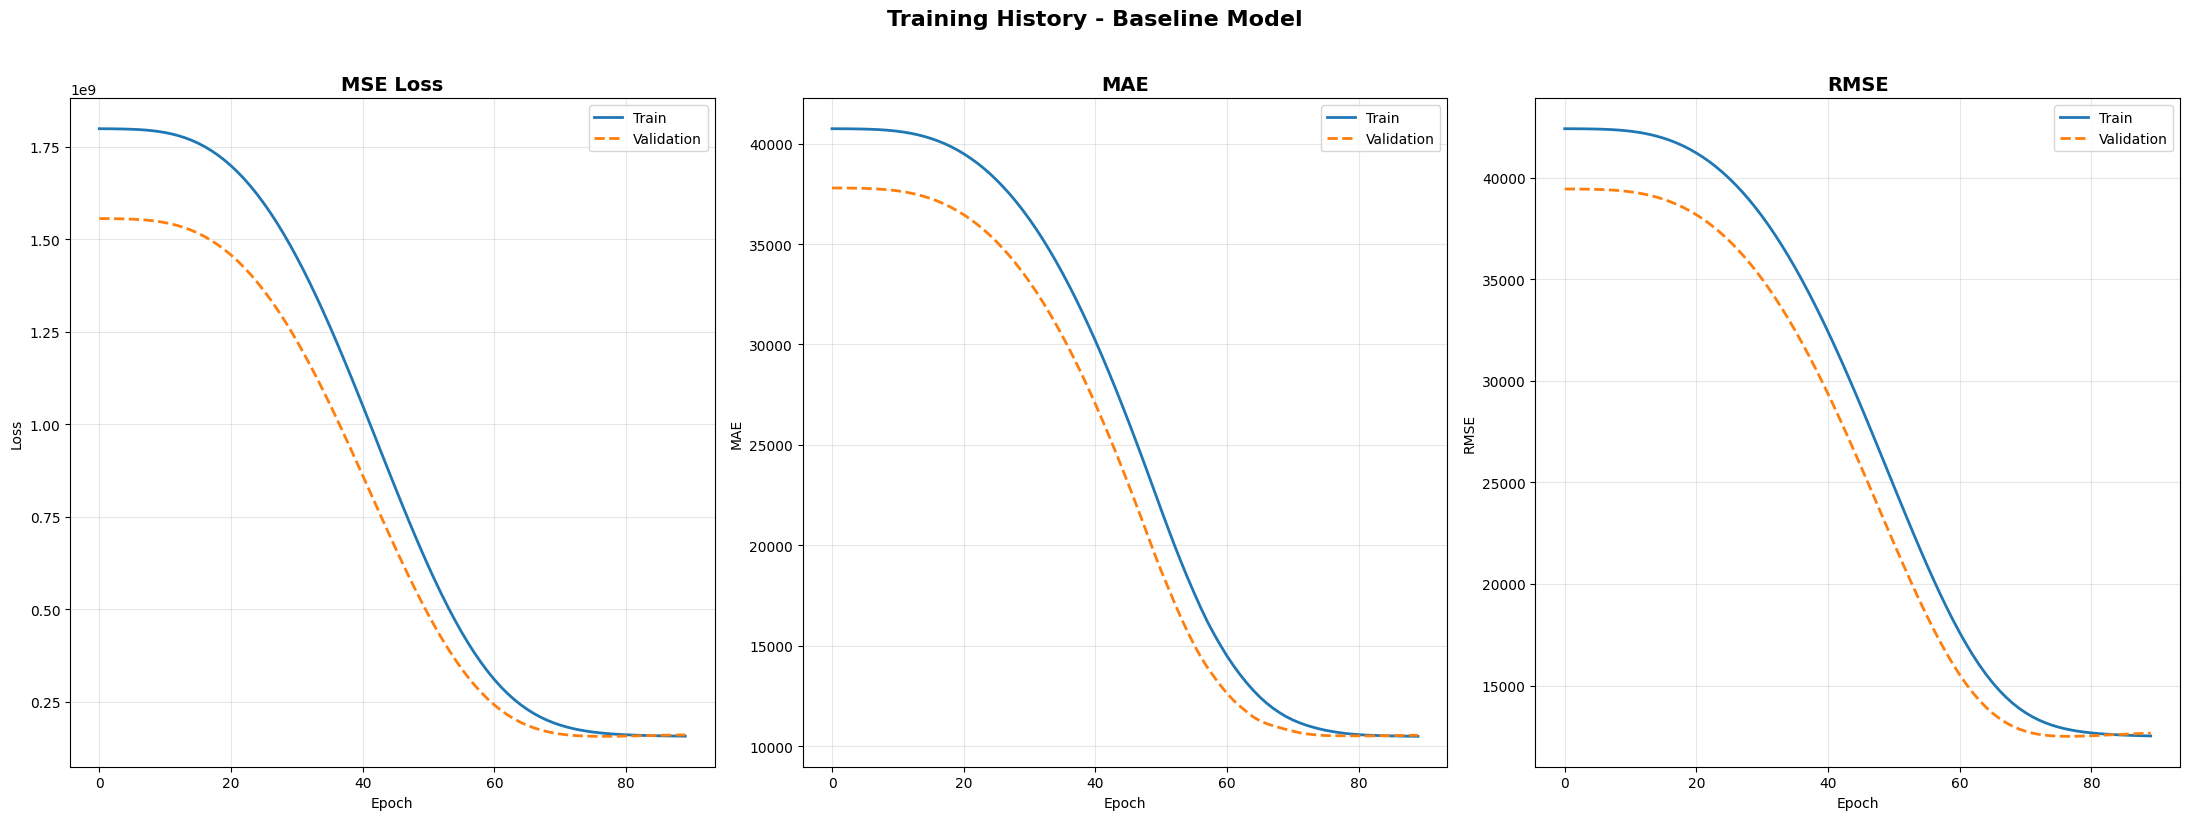

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
R^2: -0.14278738229832788
MAE: 10484.805042968748
RMSE: 12562.879657713642
MAPE: 0.290944085858379


In [27]:
plt.figure(figsize=(22, 8))

metrics = [
    ('loss', 'val_loss', 'MSE Loss', 'Loss'),
    ('mae', 'val_mae', 'MAE', 'MAE'),
    ('rmse', 'val_rmse', 'RMSE', 'RMSE'),
]

for i, (train_key, val_key, title, ylabel) in enumerate(metrics, 1):
    plt.subplot(1, 3, i)
    
    plt.plot(base_run.history[train_key], label='Train', linewidth=2)
    plt.plot(base_run.history[val_key], label='Validation', linewidth=2, linestyle='--')
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.suptitle('Training History - Baseline Model', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

base_pred = baseline_model.predict(x_test)
base_r2 = r2_score(y_test, base_pred)
base_mae = mean_absolute_error(y_test, base_pred)
base_rmse = root_mean_squared_error(y_test, base_pred)
base_mape = mean_absolute_percentage_error(y_test, base_pred)

print("R^2:", base_r2)
print("MAE:", base_mae)
print("RMSE:", base_rmse)
print("MAPE:", base_mape)

In [28]:
train_pred = baseline_model.predict(x_train)
train_r2 = r2_score(y_train, train_pred)
print(f"Train R^2: {train_r2}")

val_pred = baseline_model.predict(x_val)
val_r2 = r2_score(y_val, val_pred)
print(f"Val R^2:   {val_r2}")

test_pred = baseline_model.predict(x_test)
test_r2 = r2_score(y_test, test_pred)
print(f"Test R^2:  {test_r2}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Train R^2: -0.13476123976747378
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Val R^2:   -0.26146547138101606
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Test R^2:  -0.14278738229832788


Dari plot training history baseline model terlihat bahwa tidak ada indikasi overfitting dimana train dan validation loss konvergen bersamaan. Namun, jika dilihat dari hasil evaluasi metric regresi, baseline model menunjukkan nilai R-squared yang negatif menunjukkan model bahkan lebih buruk dari sekadar menebak nilai rata-rata. Nilai MAE dan RMSE juga cukup tinggi. Jika dibandingkan R-square untuk prediksi data train, val, dan test. Terlihat bahwa ketiganya memiliki performa yang buruk.. Hal ini mengindikasikan adanya underfit dimana model terlalu sederhana untuk menangkap pola yang ada pada data. Untuk mengatasi underfit ini, saya akan menambah kompleksitas model menambah jumlah hidden layer dan neuron. 

# c) Model Modification

In [29]:
tf.keras.utils.set_random_seed(123)
modified_model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

modified_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,  
    verbose=1
)

modified_run = modified_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=90,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1790114048.0000 - mae: 40515.0859 - rmse: 42308.4961 - val_loss: 1555325568.0000 - val_mae: 37793.7734 - val_rmse: 39437.6172
Epoch 2/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1789910144.0000 - mae: 40512.5586 - rmse: 42306.0859 - val_loss: 1555000576.0000 - val_mae: 37789.4453 - val_rmse: 39433.4961
Epoch 3/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1789474688.0000 - mae: 40507.1641 - rmse: 42300.9375 - val_loss: 1554299392.0000 - val_mae: 37780.1094 - val_rmse: 39424.6055
Epoch 4/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1788529664.0000 - mae: 40495.4609 - rmse: 42289.7656 - val_loss: 1552800128.0000 - val_mae: 37760.1367 - val_rmse: 39405.5859
Epoch 5/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1786534144.0000 - mae: 40470.7500 - rmse: 42266.1602 - val_loss: 1549747200.0000 - val_mae: 37719.4297 - val_rmse: 39366.8281
Epoch 6/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1782540544.0000 

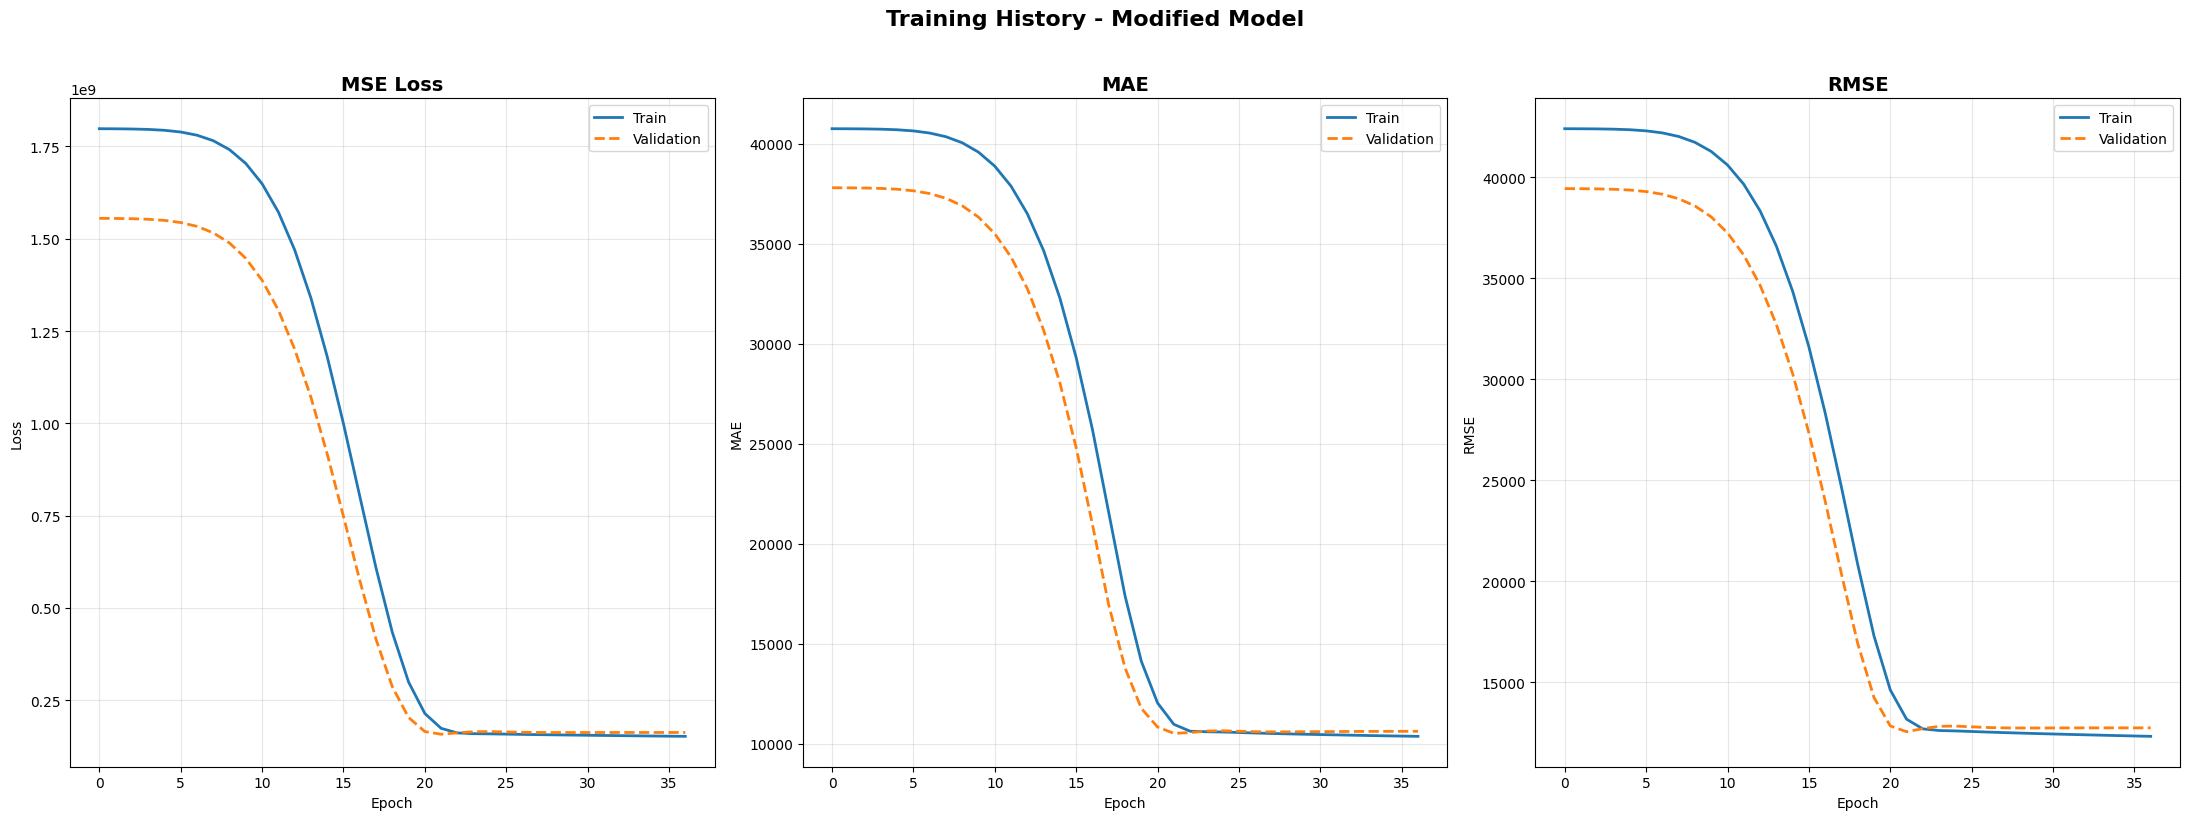

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
R^2: -0.13583923121938768
MAE: 10630.142039062499
RMSE: 12524.630254931824
MAPE: 0.2833598139851674


In [30]:
plt.figure(figsize=(22, 8))

metrics = [
    ('loss', 'val_loss', 'MSE Loss', 'Loss'),
    ('mae', 'val_mae', 'MAE', 'MAE'),
    ('rmse', 'val_rmse', 'RMSE', 'RMSE'),
]

for i, (train_key, val_key, title, ylabel) in enumerate(metrics, 1):
    plt.subplot(1, 3, i)
    
    plt.plot(modified_run.history[train_key], label='Train', linewidth=2)
    plt.plot(modified_run.history[val_key], label='Validation', linewidth=2, linestyle='--')
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.suptitle('Training History - Modified Model', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

modif_pred = modified_model.predict(x_test)
modif_r2 = r2_score(y_test, modif_pred)
modif_mae = mean_absolute_error(y_test, modif_pred)
modif_rmse = root_mean_squared_error(y_test, modif_pred)
modif_mape = mean_absolute_percentage_error(y_test, modif_pred)

print("R^2:", modif_r2)
print("MAE:", modif_mae)
print("RMSE:", modif_rmse)
print("MAPE:", modif_mape)

Grafik training history menunjukkan bahwa proses optimasi model berjalan sangat stabil dan sehat secara matematis, yang ditandai dengan penurunan kurva MSE, MAE, dan RMSE yang sangat mulus serta konvergensi yang konsisten antara data train dan validation setelah epoch 20. Tidak adanya celah (gap) yang lebar antara kedua garis tersebut mengindikasikan bahwa model tidak mengalami overfitting maupun underfitting yang ekstrem dalam konteks proses belajarnya. Namun, realitas performa model berbanding terbalik dengan keindahan grafiknya; nilai R^2 yang negatif (-0.1358) mengungkapkan bahwa model sebenarnya gagal menangkap pola hubungan antara fitur input dengan hasil panen (yield), sehingga prediksinya bahkan lebih buruk daripada sekadar menggunakan nilai rata-rata dataset sebagai jawaban.

# d) Evaluation

In [31]:
comparison_df = pd.DataFrame({
    'Metric': ['R²', 'RMSE', 'MAE', 'MAPE'],
    'Base Model': [base_r2, base_rmse, base_mae, base_mape],
    'Modified Model': [modif_r2, modif_rmse, modif_mae, modif_mape]
})
comparison_df_t = comparison_df.set_index('Metric').T

comparison_df_t

Metric,R²,RMSE,MAE,MAPE
Base Model,-0.142787,12562.879658,10484.805043,0.290944
Modified Model,-0.135839,12524.630255,10630.142039,0.283360


Peningkatan kompleksitas arsitektur ANN dari 2 hidden layer (84–56 neuron) menjadi 3 hidden layer (128–64–32 neuron) disertai early_stop tidak menghasilkan perbaikan performa yang signifikan. Hal ini terlihat dari nilai R^2 yang tetap negatif pada kedua model (−0.142 pada base model dan −0.136 pada modified model), yang mengindikasikan bahwa model belum mampu menangkap hubungan yang bermakna antara fitur dan target.

Meskipun terdapat sedikit perbaikan pada metrik RMSE dan MAPE, selisih yang dihasilkan sangat kecil sehingga tidak dapat dianggap sebagai peningkatan yang signifikan secara praktis. Temuan ini menunjukkan bahwa peningkatan kompleksitas model tidak secara otomatis meningkatkan performa.

Kondisi ini kemungkinan disebabkan oleh rendahnya relevansi fitur terhadap target, di mana sebagian besar fitur memiliki korelasi yang sangat lemah (kurang dari 0.1) terhadap variabel yield, sehingga kontribusinya dalam proses prediksi menjadi tidak signifikan.

Selain itu, dilakukan perbandingan dengan model machine learning lainnya, mengingat data tabular umumnya lebih efektif dimodelkan menggunakan pendekatan berbasis tree dibandingkan dengan ANN. Hal ini bertujuan untuk memastikan apakah keterbatasan performa berasal dari pemilihan model atau memang dari karakteristik data itu sendiri.

## Bandingkan dengan Machine Learning

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

mean_pred = np.full_like(y_test, y_train.mean(), dtype=float)

results = []

ml_models = {
    'Linear Regression': LinearRegression(),
    'SVR (RBF)': SVR(kernel='rbf'),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
}

for name, model in ml_models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    results.append({
        'Model': name,
        'R²': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': root_mean_squared_error(y_test, y_pred),
        'MAPE': mean_absolute_percentage_error(y_test, y_pred)
    })

benchmark_df = pd.DataFrame(results)
benchmark_df

,Model,R²,MAE,RMSE,MAPE
0,Linear Regression,-0.085337,10934.436284,12243.024587,0.313972
1,SVR (RBF),-0.004161,10514.079109,11776.278285,0.305414
2,Random Forest,-0.072458,10655.093630,12170.169776,0.301322
3,Gradient Boosting,-0.174737,10932.455895,12737.281534,0.301954
4,XGBoost,-0.351477,11490.014437,13661.890508,0.319747


Beberapa model machine learning menunjukkan kinerja yang lebih baik dibandingkan ANN. Namun, nilai R^2 yang tetap negatif pada seluruh model mengindikasikan bahwa model belum mampu menangkap hubungan yang bermakna antara fitur dan target.

Hal ini menunjukkan bahwa rendahnya performa tidak semata-mata disebabkan oleh keterbatasan jumlah data (~500 observasi) atau ketidakmampuan ANN dalam memodelkan pola, melainkan lebih mengarah pada kualitas data dan rendahnya relevansi fitur yang digunakan.

Meskipun demikian, jika harus memilih antara baseline model dan modified model, maka modified model lebih dipilih karena menunjukkan performa yang secara konsisten sedikit lebih baik pada beberapa metrik evaluasi. Namun, perlu dicatat bahwa peningkatan tersebut bersifat marginal sehingga belum memberikan perbedaan yang signifikan secara praktis.

# e) Video Penjelasan